# Изучение диаметров интерференционных колец

Обрабатываем датасет с положением центра интеференционного кольца. Данные получены по шкале микрометрического винта и пересчитаны по следующей рекуррентной формуле 

$x_{i + 1} = (\phi_{i} - \phi_{i + 1}) \mod 100 + x_{i}$

где $\phi_i$ --- координата шкалы микрометрического винта, соответствующее положению центра интерференционного кольца

In [134]:
# 561 деление микрометрического винта = 0.5 мм => 
# 548 делений 0.5 мм +- 2 % 
delta = 0.5 / 554.5 # mm 
xrerr = 0.02

In [121]:
import pandas as pd
import numpy as np 


import matplotlib.pyplot as plt
import numpy as np


rings_data = pd.read_csv('data/rings.csv', sep = '\t')
rings_data['x'] *= delta #mm 

light = rings_data.loc[rings_data['color'] == 1]

dark = rings_data.loc[rings_data['color'] == 0]



display(rings_data.head())

,n,phi,x,color,ringidx,ringidxc
0,1,78,0.000000,0,20,10
1,2,69,0.008021,1,19,10
2,3,61,0.015152,0,18,9
3,4,54,0.021390,1,17,9
4,5,46,0.028520,0,16,8


In [122]:
x0_idx = 20

left = rings_data[:x0_idx]
right = rings_data[x0_idx:]



In [123]:
x0 = np.mean(rings_data['x'][6:])

print(x0)

0.26461038961038963


# Глупая картинка

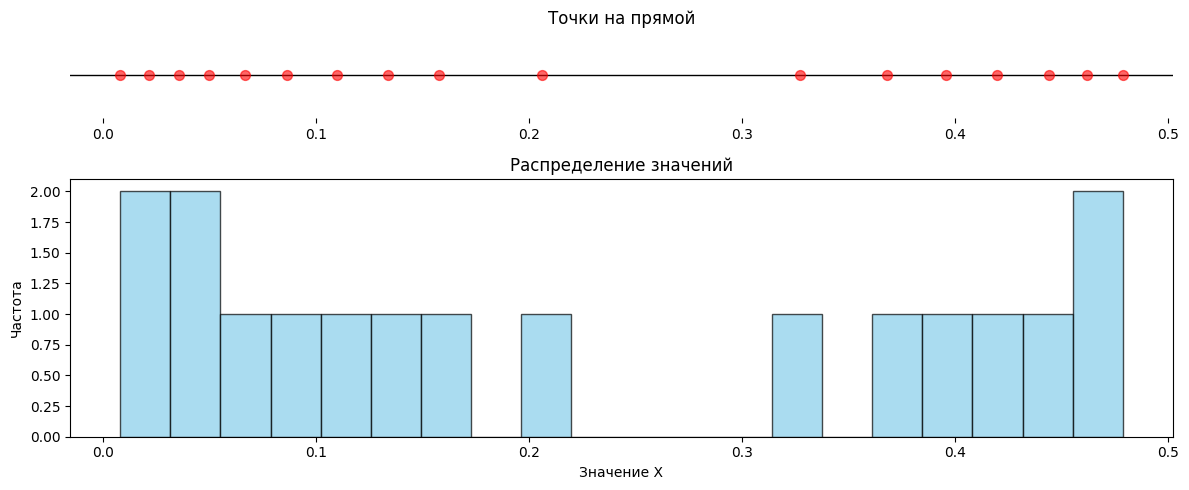

In [124]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
x_points = light['x']

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), 
                               gridspec_kw={'height_ratios': [1, 3]})

# Верхний график - точки на линии
ax1.axhline(y=0, color='black', linewidth=1)
ax1.scatter(x_points, np.zeros_like(x_points), 
           color='red', s=50, alpha=0.6, zorder=5)
ax1.set_ylim(-0.5, 0.5)
ax1.yaxis.set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.set_title('Точки на прямой')

# Нижний график - гистограмма распределения
ax2.hist(x_points, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
ax2.set_xlabel('Значение X')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение значений')

plt.tight_layout()
plt.show()

# Прямые $r_m^2$ и $r_m'^2$

In [125]:
import numpy as np

def lsq(x: np.ndarray, y: np.ndarray):
    ''' 
    Расчет коэффициентов прямой и их погрешностей по стандартным формулам при аппроксимации вида y = A*x + B
    '''
    A, B = np.polyfit(x, y, 1)
    residuals = y - (A * x + B)
    s2 = np.var(residuals, ddof=2)
    Sxx = np.var(x, ddof=1) * (len(x) - 1)
    
    A_err = np.sqrt(s2 / Sxx)
    B_err = np.sqrt(s2 * (1/len(x) + np.mean(x)**2 / Sxx))
    
    return A, A_err, B, B_err

Радиус кривизны линзы 12.750719753470845 +- 0.07867307186695674 мм


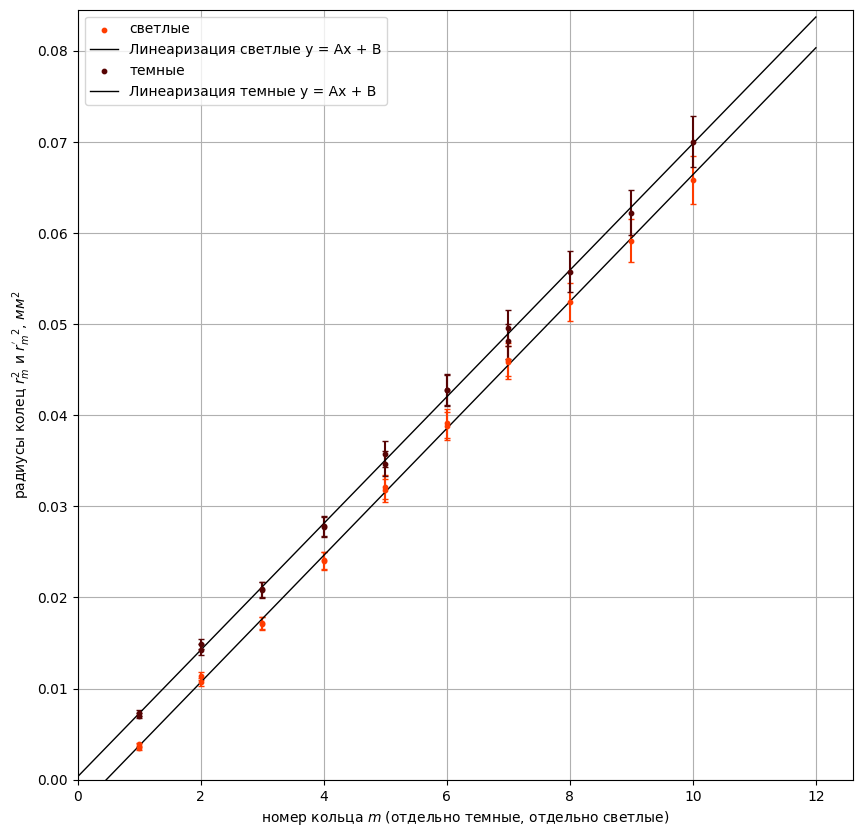

In [149]:



def linearized_radline (data : pd.DataFrame, x0 : float, ax: plt.Axes, color : str, name : str): 
    ''' 
    data : np.ndarray
        data должен содержать столбцы x и ringidx

    x0 : float 
    ax : plt.Axes
    '''

    A,A_err, B, B_err = lsq(data['ringidxc'],(data['x'] - x0) ** 2)


    ax.scatter(data['ringidxc'], (data['x'] - x0)** 2, color = color, label = name, s = 10, zorder = 10) 
    ax.errorbar(data['ringidxc'], (data['x'] - x0) ** 2, yerr = (data['x'] - x0) ** 2 * (xrerr * 2), linestyle = '', color = color, capsize = 2)

    ax.plot(np.linspace(0, max(data['ringidxc']) * 1.2) , A * np.linspace(0, max(data['ringidxc']) * 1.2) + B, color = 'black', linewidth = 1, label = f'Линеаризация {name} y = Ax + B')
    
    plt.xlim(0)
    plt.ylim(0)
    plt.legend()
    return A, A_err, B, B_err 


fig, axs = plt.subplots(figsize = (10,10))

A, A_err, B, B_err = linearized_radline(light, x0, axs, "#FF3C00", 'светлые')
linearized_radline(dark, x0, axs, "#570404", 'темные')

# Ad,Ad_err, Bd, Bd_err = lsq(dark['ringidx'],dark['x'] - x0)

# plt.scatter(light['ringidx'], np.abs(light['x'] - x0) ** 2, s = 10, color = 'coral')

# plt.scatter(dark['ringidx'], np.abs(dark['x'] - x0) ** 2, s = 10, color = 'maroon')
plt.xlabel('номер кольца $m$ (отдельно темные, отдельно светлые)')
plt.ylabel(r"радиусы колец $r_m^2$ и ${r_m ^{'}}^2$, $мм^2$")
plt.grid()



def curvrad (lam : float, lR : float, lR_err : float):
    
    return lR / lam, lR_err / lam 
    

green = 546 * 1e-6
R, R_err = curvrad(green, A, A_err)
print(f'Радиус кривизны линзы {R} +- {R_err} мм')


In [129]:
np.sqrt(0.08)

np.float64(0.282842712474619)

# Смешная картинка

In [127]:
def ringsPlot(x: np.ndarray, color_pattern: np.ndarray, ax: plt.Axes, 
                       base_color: str = 'green', dark_factor: float = 0.3,
                       show_guides: bool = True):
    ''' 
    Расширенная версия с настройкой степени затемнения
    
    Parameters:
    x : np.ndarray 
        координаты центров полос колец (радиусы)
    color_pattern : np.ndarray
        массив из 0 и 1, определяющий чередование цветов
    ax : plt.Axes
        объект осей matplotlib
    base_color : str
        базовый цвет для колец
    dark_factor : float
        коэффициент затемнения для темных колец (0-1, меньше - темнее)
    show_guides : bool
        показывать ли направляющие линии
    '''
    
    center_x, center_y = 0, 0
    n_rings = len(x)
    
    if len(color_pattern) != n_rings:
        raise ValueError(f"Длина color_pattern ({len(color_pattern)}) не совпадает с количеством колец ({n_rings})")
    
    theta = np.linspace(0, 2*np.pi, 200)  # больше точек для гладкости
    
    # Получаем RGB базового цвета один раз
    base_rgb = np.array(plt.matplotlib.colors.to_rgb(base_color))
    
    for i, (radius, pattern) in enumerate(zip(x, color_pattern)):
        # Определяем цвет для текущего кольца
        if pattern == 1:
            color = base_color  # яркое кольцо
            alpha = 0.9
            linewidth = 2.5
        else:
            # Темное кольцо
            dark_rgb = base_rgb * dark_factor
            color = dark_rgb
            alpha = 0.7
            linewidth = 2.0
        
        # Координаты окружности
        x_circle = center_x + radius * np.cos(theta)
        y_circle = center_y + radius * np.sin(theta)
        
        # Рисуем окружность
        ax.plot(x_circle, y_circle, color=color, linewidth=linewidth, alpha=alpha)
        
        # Добавляем отметку центра полосы
        mark_x = center_x + radius * np.cos(np.pi/4)
        mark_y = center_y + radius * np.sin(np.pi/4)
        ax.plot(mark_x, mark_y, 'o', color=color, markersize=6, alpha=alpha)
        
        # Направляющие линии (опционально)
        if show_guides and i % 3 == 0:
            ax.plot([center_x, mark_x], [center_y, mark_y], 
                   '--', color=color, linewidth=1, alpha=0.3)
    
    # Центральная точка
    ax.plot(center_x, center_y, 'k+', markersize=15, markeredgewidth=3, label='Центр')
    
    # Добавляем небольшую легенду для цветов
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=base_color, alpha=0.9, label='Яркое кольцо (1)'),
        Patch(facecolor=base_rgb * dark_factor, alpha=0.7, label='Темное кольцо (0)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Настройки осей
    ax.set_aspect('equal')
    ax.set_xlabel('X координата')
    ax.set_ylabel('Y координата')
    ax.set_title(f'Кольца Ньютона (базовый цвет: {base_color})')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Границы
    max_radius = max(x)
    margin = max_radius * 0.5
    ax.set_xlim(-max_radius - margin, max_radius + margin)
    ax.set_ylim(-max_radius - margin, max_radius + margin)



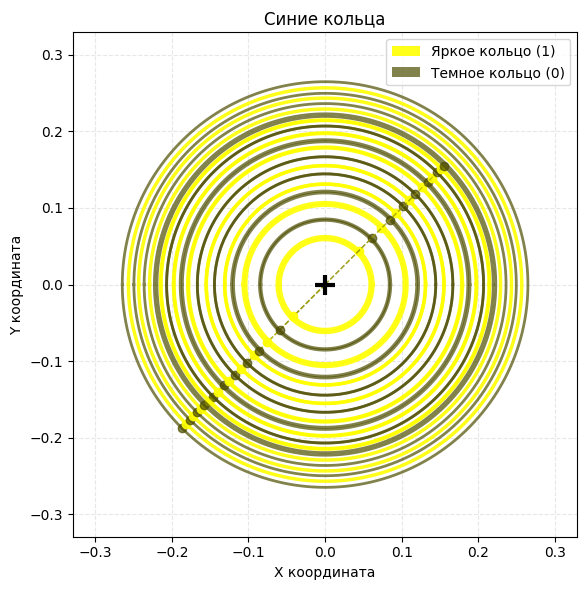

In [128]:

fig, axs = plt.subplots(figsize=(6, 6))
ringsPlot(rings_data['x'] - x0, rings_data['color'], axs, 'yellow')
axs.set_title('Синие кольца')
plt.tight_layout()
plt.show()

# Биения

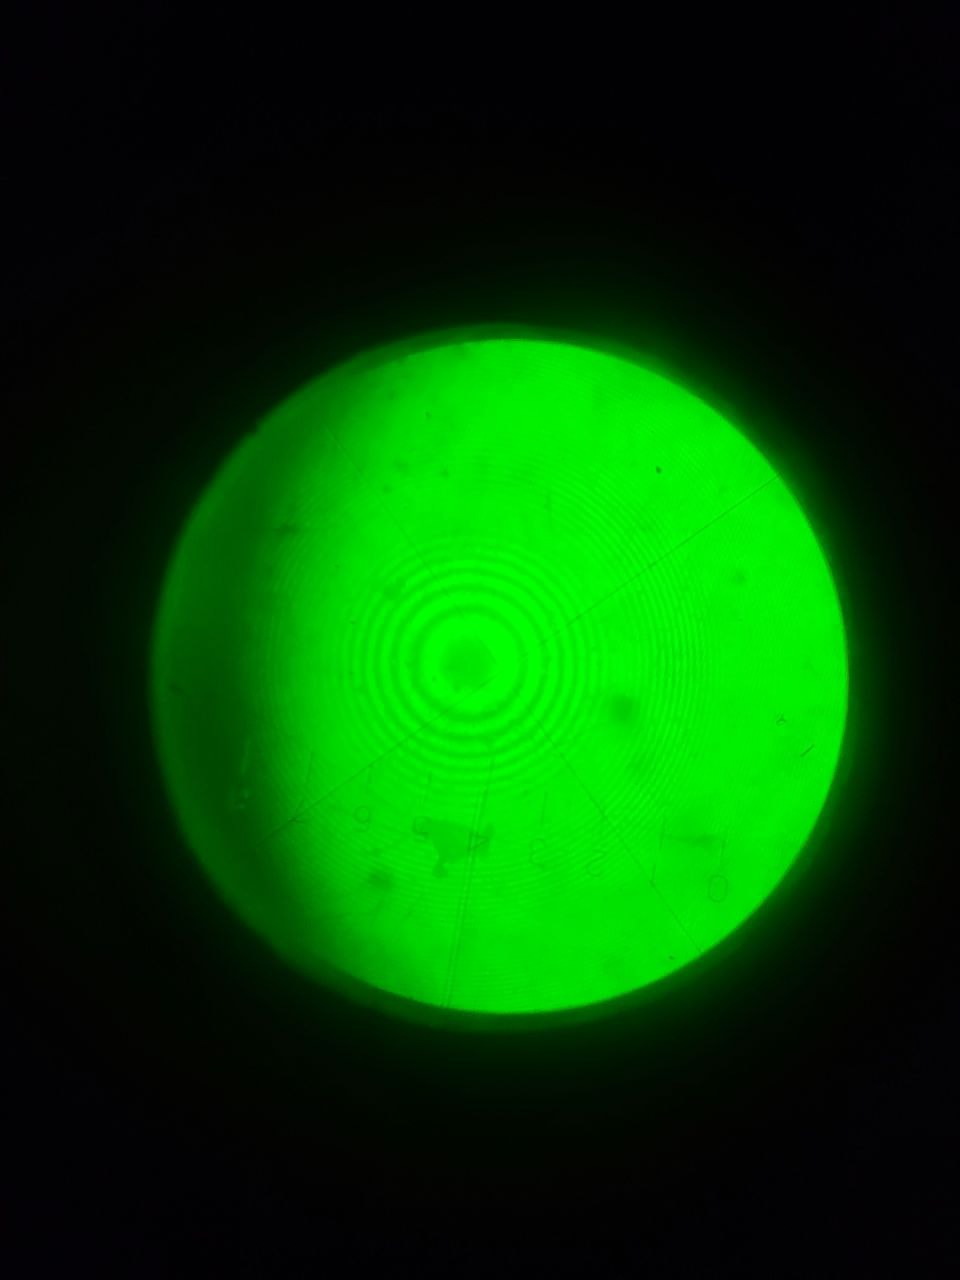
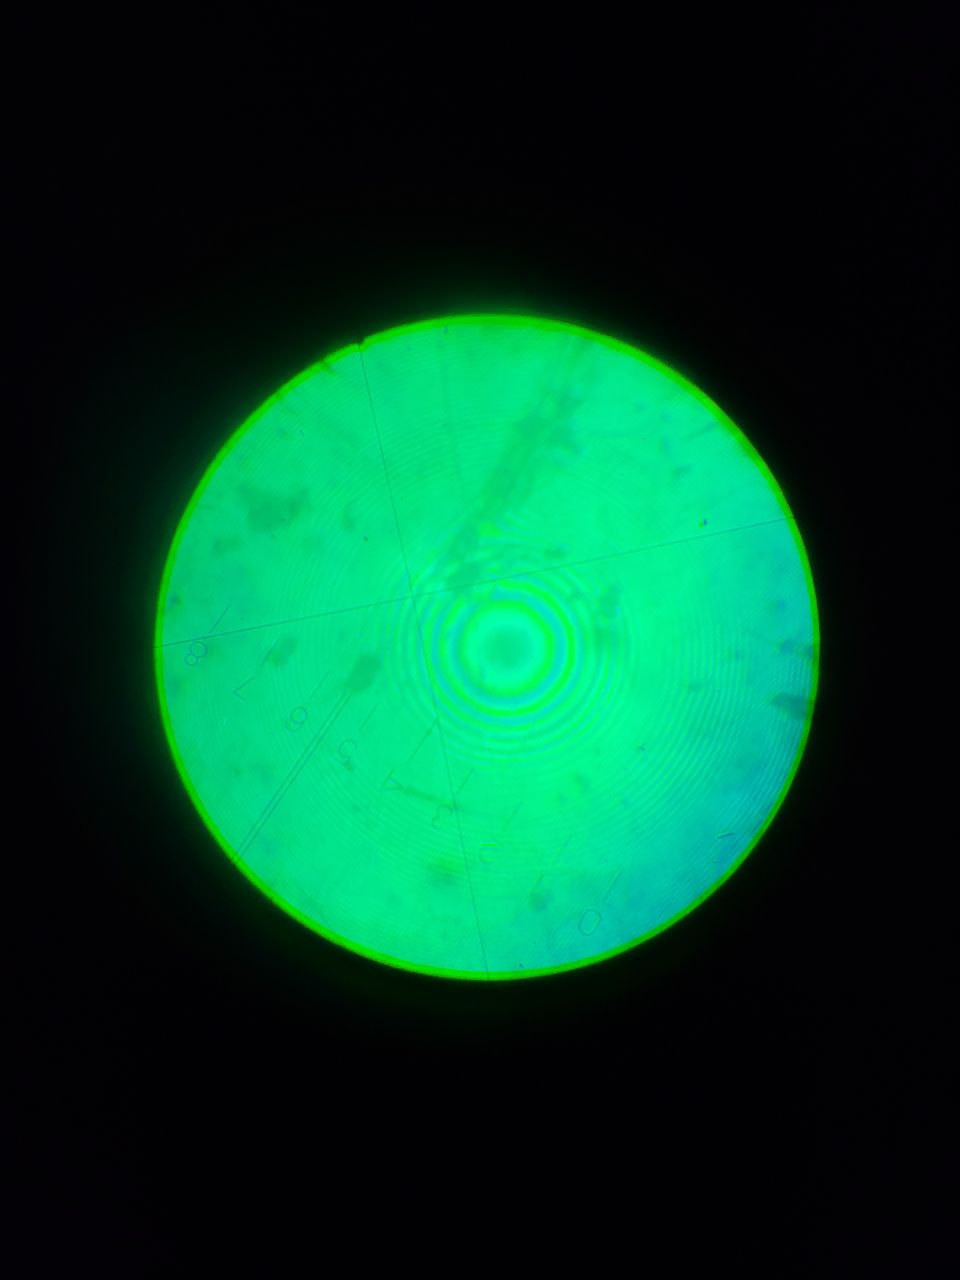

$\lambda_1 = 546$ --- зеленый, $\lambda_2 = 758$ --- желтый, https://ru.wikipedia.org/wiki/Ртутная_газоразрядная_лампа
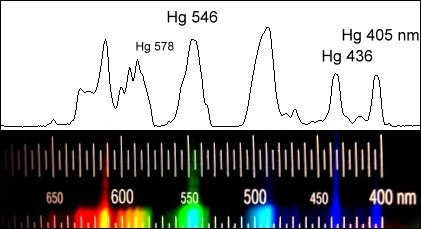

Различимо что-то типа 16 колец, значит $\lambda_1 * 16 = \lambda_2 * 15$ $\lambda_2 - \lambda_1 = $1/15$ $\lambda_1 \approx 36,4$ нм 